# 03 — Train the U-Net

This notebook trains a U-Net to predict pressure and velocity fields from geometry and flow conditions.

In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch: 2.12.1+cu126
Device: cuda
GPU: NVIDIA GeForce GTX 1650
VRAM: 4.29 GB


## 1. Load the data

Use the processed dataset created in notebook 02.

In [2]:
DATA_PATH = "../data/processed.npz"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

data = np.load(DATA_PATH)
X = data["X"]  # (800, 3, 128, 128) - inputs
Y = data["Y"]  # (800, 3, 128, 128) - outputs

# Statistics for later denormalization
Y_mean = data["Y_mean"]
Y_std = data["Y_std"]

print(f"X: {X.shape}, dtype={X.dtype}")
print(f"Y: {Y.shape}, dtype={Y.dtype}")
print(f"Velikost v pameti: {(X.nbytes + Y.nbytes)/1e6:.0f} MB")

X: (800, 3, 128, 128), dtype=float32
Y: (800, 3, 128, 128), dtype=float32
Velikost v pameti: 315 MB


## 2. Prepare the dataset

Create PyTorch data loaders for training and validation.

In [3]:
class AirfoilDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


full_dataset = AirfoilDataset(X, Y)
print(f"Dataset: {len(full_dataset)} samples")

# Test - one sample
x_sample, y_sample = full_dataset[0]
print(f"One input: {x_sample.shape}")
print(f"One output: {y_sample.shape}")

Dataset: 800 vzorku
Jeden vstup: torch.Size([3, 128, 128])
Jeden vystup: torch.Size([3, 128, 128])


## 3. Build the model

A segmentation-style U-Net is used for this regression task.

In [10]:
BATCH_SIZE = 16

# Split 720 / 80
n_val = 80
n_train = len(full_dataset) - n_val
train_ds, val_ds = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)  # reprodukovatelne
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Trenink: {len(train_ds)} vzorku ({len(train_loader)} batchu)")
print(f"Validace: {len(val_ds)} vzorku ({len(val_loader)} batchu)")
print(f"Batch size: {BATCH_SIZE}")

Trenink: 720 vzorku (45 batchu)
Validace: 80 vzorku (5 batchu)
Batch size: 16


## 4. Define the loss

The model is optimized with MSE loss and Adam.

In [5]:
import segmentation_models_pytorch as smp

def build_unet():
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=3,
    )

model = build_unet().to(device)

# Pocet parametru
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net postaven: {n_params/1e6:.1f}M parametru")
print(f"Encoder: ResNet34 (predtrenovany)")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

f:\AI_projekt\Code\airfoil-ai\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\marti\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net postaven: 24.4M parametru
Encoder: ResNet34 (predtrenovany)


## 5. Run a smoke test

Start with one epoch to confirm that training works.

In [6]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Loss: MSE")
print("Optimizer: Adam, lr=1e-3")

Loss: MSE
Optimizer: Adam, lr=1e-3


## 6. Train the full model

Run the full training loop and save the best checkpoint.

In [8]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for X_batch, Y_batch in loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

        optimizer.zero_grad()       # vynuluj gradienty
        pred = model(X_batch)        # forward pass
        loss = loss_fn(pred, Y_batch)  # spocitej loss
        loss.backward()              # backward pass (gradienty)
        optimizer.step()             # uprav vahy

        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    for X_batch, Y_batch in loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        pred = model(X_batch)
        total_loss += loss_fn(pred, Y_batch).item()
    return total_loss / len(loader)

print("Funkce train_one_epoch a validate pripraveny.")

Funkce train_one_epoch a validate pripraveny.


## 7. Inspect the loss curve

Check whether training and validation loss are both improving.

In [9]:
print("=== SMOKE TEST: 1 epocha ===\n")

start = time.time()
train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
val_loss = validate(model, val_loader, loss_fn, device)
elapsed = time.time() - start

print(f"Train loss: {train_loss:.4f}")
print(f"Val loss:   {val_loss:.4f}")
print(f"Cas 1 epochy: {elapsed:.1f}s")
print(f"\nOdhad pro 50 epoch: {elapsed*50/60:.0f} minut")

# Kontrola VRAM
if device == "cuda":
    print(f"VRAM pouzito: {torch.cuda.max_memory_allocated()/1e9:.2f} GB / "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")

=== SMOKE TEST: 1 epocha ===

Train loss: 0.3979
Val loss:   0.1497
Cas 1 epochy: 14.7s

Odhad pro 50 epoch: 12 minut
VRAM pouzito: 0.52 GB / 4.29 GB


## 8. Compare predictions

Inspect a few example outputs to judge the model quality.

## 9. Summary

The trained model is ready for evaluation.

In [11]:
# Cisty restart pro plny trenink
model = build_unet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

print("Model resetovan, pripraven na plny trenink.")

Model resetovan, pripraven na plny trenink.


## 10. Done

The notebook now contains only the essential notes.

In [12]:
EPOCHS = 50
CHECKPOINT_PATH = os.path.join(MODELS_DIR, "best_model.pth")
LAST_PATH = os.path.join(MODELS_DIR, "last_model.pth")
LOG_PATH = os.path.join(MODELS_DIR, "training_log.txt")

print(f"Epoch: {EPOCHS}")
print(f"Nejlepsi model -> {CHECKPOINT_PATH}")
print(f"Posledni model -> {LAST_PATH}")
print(f"Log -> {LOG_PATH}")

Epoch: 50
Nejlepsi model -> ../models\best_model.pth
Posledni model -> ../models\last_model.pth
Log -> ../models\training_log.txt


This section is kept brief.

In [13]:
train_history = []
val_history = []
best_val_loss = float("inf")

# Zacatek logu
with open(LOG_PATH, "w") as f:
    f.write(f"Training started: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Epochs: {EPOCHS}, Batch size: {BATCH_SIZE}, Device: {device}\n\n")

print(f"=== PLNY TRENINK: {EPOCHS} epoch ===\n")
total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss = validate(model, val_loader, loss_fn, device)

    train_history.append(train_loss)
    val_history.append(val_loss)
    epoch_time = time.time() - epoch_start

    # Uloz posledni model (ochrana pri padu)
    torch.save(model.state_dict(), LAST_PATH)

    # Uloz nejlepsi model
    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        marker = " <- best"

    # Log
    line = (f"Epoch {epoch:3d}/{EPOCHS}  "
            f"train={train_loss:.4f}  val={val_loss:.4f}  "
            f"({epoch_time:.0f}s){marker}")
    print(line)
    with open(LOG_PATH, "a") as f:
        f.write(line + "\n")

total_time = time.time() - total_start
print(f"\n=== HOTOVO za {total_time/60:.0f} minut ===")
print(f"Nejlepsi val loss: {best_val_loss:.4f}")
print(f"Model ulozen: {CHECKPOINT_PATH}")

=== PLNY TRENINK: 50 epoch ===

Epoch   1/50  train=0.3131  val=0.2655  (8s) <- best
Epoch   2/50  train=0.1767  val=0.1056  (8s) <- best
Epoch   3/50  train=0.1695  val=0.0879  (8s) <- best
Epoch   4/50  train=0.1282  val=0.0603  (8s) <- best
Epoch   5/50  train=0.1233  val=0.0591  (8s) <- best
Epoch   6/50  train=0.1092  val=0.0542  (8s) <- best
Epoch   7/50  train=0.1091  val=0.0473  (8s) <- best
Epoch   8/50  train=0.1238  val=0.0415  (8s) <- best
Epoch   9/50  train=0.1065  val=0.0461  (8s)
Epoch  10/50  train=0.0956  val=0.0407  (8s) <- best
Epoch  11/50  train=0.0888  val=0.0452  (8s)
Epoch  12/50  train=0.0866  val=0.0342  (8s) <- best
Epoch  13/50  train=0.0809  val=0.0308  (8s) <- best
Epoch  14/50  train=0.0806  val=0.0441  (8s)
Epoch  15/50  train=0.0819  val=0.0512  (8s)
Epoch  16/50  train=0.0922  val=0.0358  (8s)
Epoch  17/50  train=0.0857  val=0.0618  (8s)
Epoch  18/50  train=0.0736  val=0.0365  (8s)
Epoch  19/50  train=0.0777  val=0.0337  (8s)
Epoch  20/50  train=0.086

This section is kept brief.

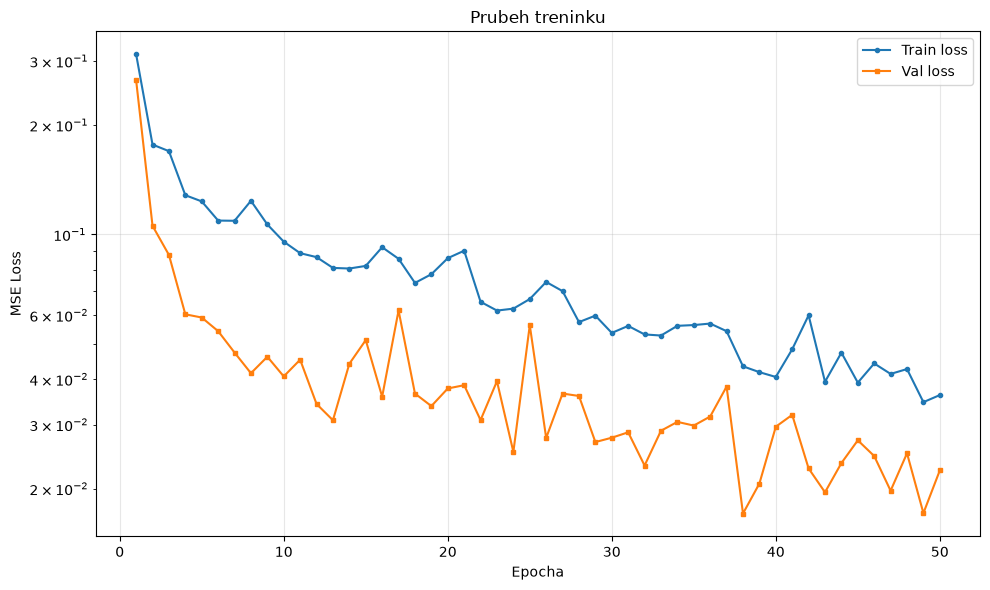

Finalni train loss: 0.0362
Finalni val loss:   0.0224
Nejlepsi val loss:  0.0171


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
epochs_range = range(1, len(train_history) + 1)
ax.plot(epochs_range, train_history, label="Train loss", marker="o", markersize=3)
ax.plot(epochs_range, val_history, label="Val loss", marker="s", markersize=3)
ax.set_xlabel("Epocha")
ax.set_ylabel("MSE Loss")
ax.set_title("Prubeh treninku")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")  # log skala - lepe videt pokles
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, "training_curve.png"), dpi=150)
plt.show()

print(f"Finalni train loss: {train_history[-1]:.4f}")
print(f"Finalni val loss:   {val_history[-1]:.4f}")
print(f"Nejlepsi val loss:  {min(val_history):.4f}")

This section is kept brief.

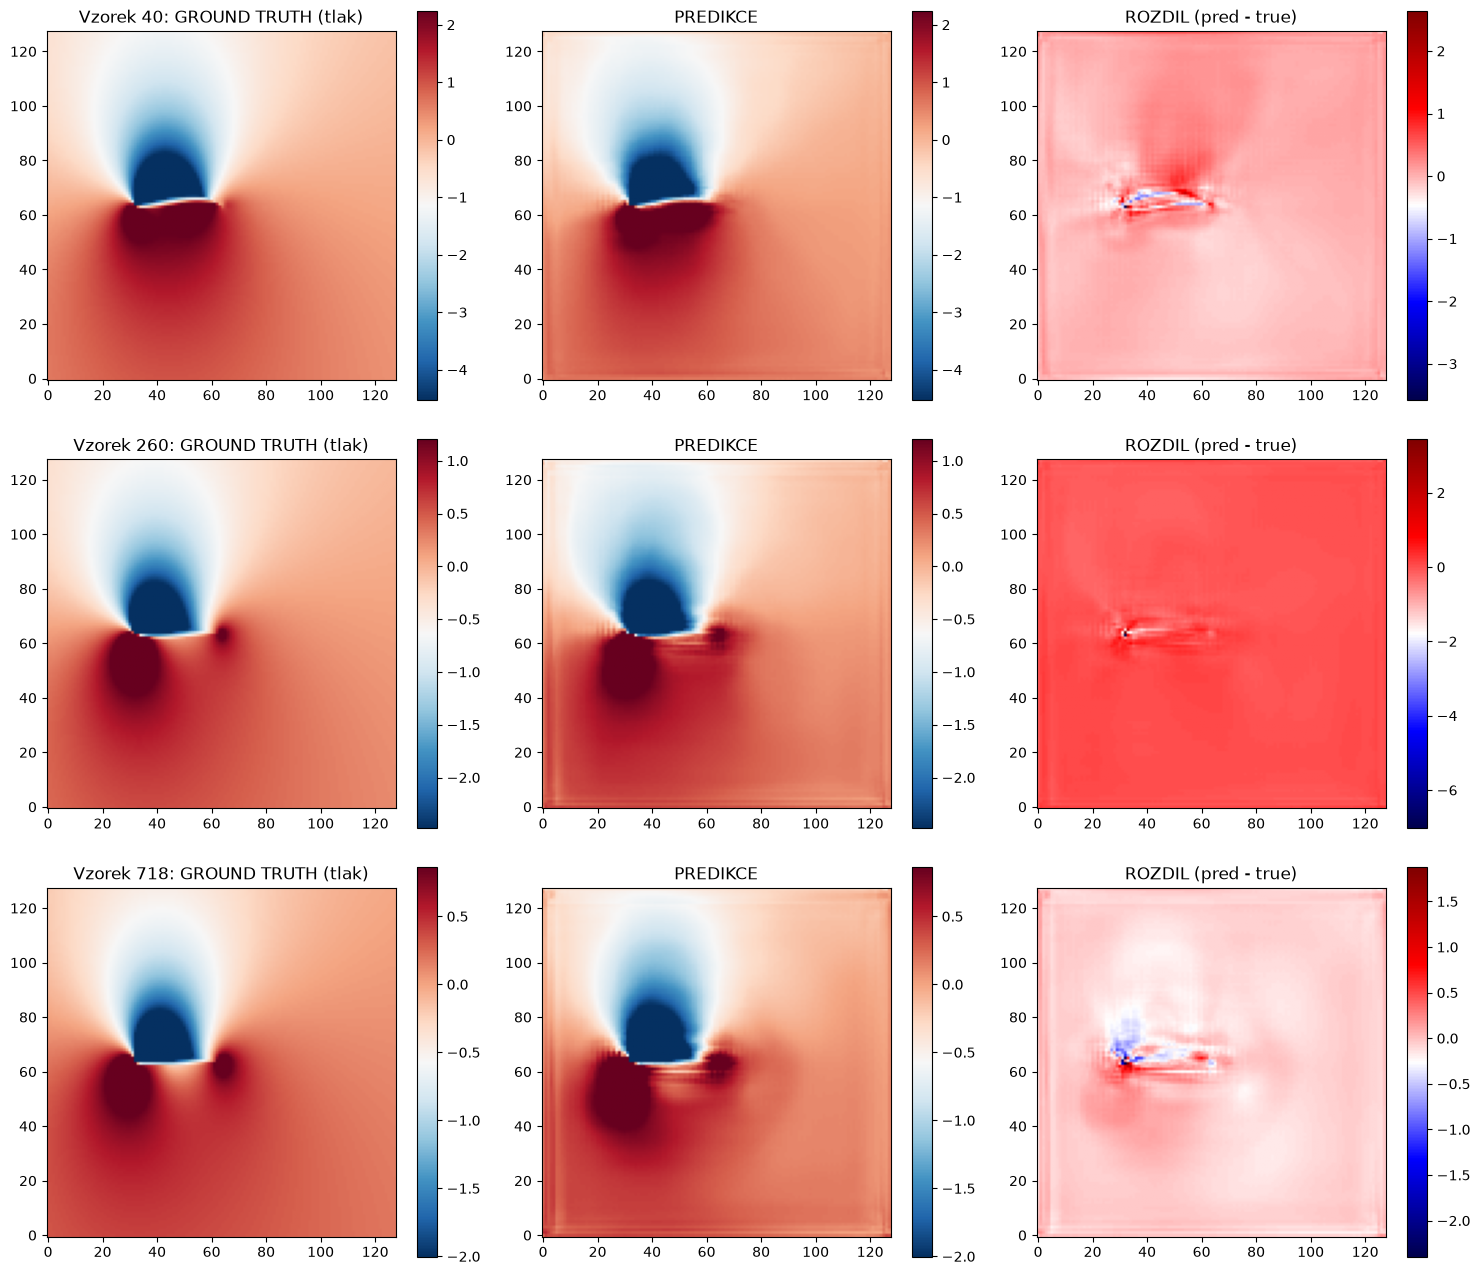

Vlevo: skutecnost | Uprostred: predikce | Vpravo: chyba


In [15]:
# Load the best model
best_model = build_unet().to(device)
best_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
best_model.eval()

# Take a few validation samples
val_indices = list(val_ds.indices[:3])

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for row, idx in enumerate(val_indices):
    x = full_dataset.X[idx:idx+1].to(device)
    y_true = full_dataset.Y[idx, 0].numpy()  # tlak (kanal 0)

    with torch.no_grad():
        y_pred = best_model(x)[0, 0].cpu().numpy()

    # Shared scale
    vmin, vmax = np.percentile(y_true, [2, 98])

    im0 = axes[row, 0].imshow(y_true, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"Sample {idx}: GROUND TRUTH (pressure)")
    plt.colorbar(im0, ax=axes[row, 0])

    im1 = axes[row, 1].imshow(y_pred, cmap="RdBu_r", origin="lower", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title("PREDICTION")
    plt.colorbar(im1, ax=axes[row, 1])

    diff = y_pred - y_true
    im2 = axes[row, 2].imshow(diff, cmap="seismic", origin="lower")
    axes[row, 2].set_title("DIFFERENCE (pred - true)")
    plt.colorbar(im2, ax=axes[row, 2])

plt.tight_layout()
plt.show()
print("Left: ground truth | Center: prediction | Right: error")

This section is kept brief.